In [1]:
import h5py as h5
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

In [2]:
path = '/home3/rfit/Telescope_Array/phd_work/data/normed/pr_photon_0001_excl_sat_T_excl_geo_T.h5'


In [3]:
with h5.File(path,'r') as f:
    mean = np.array(f['norm_param']['dt_params']['mean'][()])
    std = np.array(f['norm_param']['dt_params']['std'][()])
    print(mean, std)
    train = f['train']
    dt_params = np.array(train['dt_params'][()])
    ev_starts = np.array(train['ev_starts'][()])

    test = f['test']
    dt_params_test = np.array(test['dt_params'][()])
    ev_starts_test = np.array(test['ev_starts'][()])
    dt_params_unnorm = dt_params*np.expand_dims(std, axis=0)+np.expand_dims(mean, axis=0)
dt_params, ev_starts

[-4.0681646e-03  2.7320355e-03  1.1419018e-02  2.2748152e+01
 -7.4748051e-01  2.4137352e+00] [1.3315824e+00 1.3315184e+00 2.0426827e-02 4.4005234e+01 3.8208544e+00
 2.4776492e+00]


(array([[ 0.06934348, -1.0980862 , -1.2615968 , -0.40860644, -0.84052396,
         -0.6335583 ],
        [ 0.06934348, -1.0980862 , -1.2615968 , -0.40860644, -0.84052396,
          0.57726693],
        [-0.68354756, -1.0620898 , -1.3726517 , -0.4986827 , -0.65470165,
         -0.21784166],
        ...,
        [-0.44843253, -0.65739834, -1.299679  , -0.28245166,  0.37281725,
         -0.78208613],
        [ 1.0543907 ,  0.09309143, -1.2971382 , -0.42743853,  0.86223656,
         -0.7211413 ],
        [ 0.30390996, -0.65957254, -1.3602072 ,  0.5609116 ,  0.89416665,
         -0.8591753 ]], dtype=float32),
 array([        0,         8,        15, ..., 202245774, 202245810,
        202245823]))

In [4]:
dt_params.shape, dt_params_unnorm.shape

((202245823, 6), (202245823, 6))

In [5]:
dt_params.shape, dt_params_unnorm.shape

((202245823, 6), (202245823, 6))

In [6]:
dt_params.shape

(202245823, 6)

In [7]:
data_old = []
start = ev_starts[0] # it's 0
for ind in tqdm(ev_starts[1:]):
    data_old.append(dt_params[start:ind])
    start = ind

100%|██████████| 10291149/10291149 [00:04<00:00, 2244821.53it/s]


In [8]:
data = []
start = ev_starts[0] # it's 0
for ind in tqdm(ev_starts[1:]):
    data.append(dt_params[start:ind])
    start = ind
data_test = []
start = ev_starts_test[0] # it's 0
for ind in tqdm(ev_starts_test[1:]):
    data_test.append(dt_params_test[start:ind])
    start = ind

100%|██████████| 1143461/1143461 [00:00<00:00, 2192266.24it/s]


In [8]:
data_unnorm = []
start = ev_starts[0] # it's 0
for ind in tqdm(ev_starts[1:]):
    data_unnorm.append(dt_params_unnorm[start:ind])
    start = ind

100%|██████████| 10291149/10291149 [00:04<00:00, 2199607.53it/s]


In [9]:
def get_length(x):
    return len(x) - np.sum(x[:, 0] == -11) - 2

def double_detector(x):
    length = get_length(x)
    coords = x[:, :4]

    # Получаем уникальные строки и индексы их появления
    unique_coords, inverse_indices, counts = np.unique(coords, axis=0, return_inverse=True, return_counts=True)

    # Находим координаты-дубликаты
    duplicate_coords = unique_coords[counts > 1]

    # Находим индексы всех дубликатов в оригинальном массиве
    duplicate_indices = []
    for coord in duplicate_coords:
        matches = np.all(coords == coord, axis=1)
        indices = np.nonzero(matches)[0].tolist()
        if len(indices) > 1:
            duplicate_indices.append(indices)

    return duplicate_indices
print(double_detector(data[200]))
print(data[200])

[[10, 11], [2, 3], [7, 8, 9], [4, 5, 6]]
[[ 1.2767878   0.67978406 -0.9979601  -0.5018479  -0.3764916   0.20998326]
 [ 1.2630072  -0.7247636  -1.0100143  -0.50419873 -0.28750622 -0.2739432 ]
 [ 0.499285    0.812139   -0.9642633  -0.16729264 -0.05483577 -0.64929897]
 [ 0.499285    0.812139   -0.9642633  -0.16729264 -0.05483577  0.38393846]
 [ 0.52662086  0.04767794 -0.9793267   2.951191   -0.02107369 -0.8624042 ]
 [ 0.52662086  0.04767794 -0.9793267   2.951191   -0.02107369  0.1708332 ]
 [ 0.52662086  0.04767794 -0.9793267   2.951191   -0.02107369  1.2040707 ]
 [ 0.5253187  -0.70636725 -1.0067853  -0.1355873   0.02446587 -0.54516804]
 [ 0.5253187  -0.70636725 -1.0067853  -0.1355873   0.02446587  0.8271004 ]
 [ 0.5253187  -0.70636725 -1.0067853  -0.1355873   0.02446587  2.142864  ]
 [-0.22803082 -0.70037335 -0.9835521   0.29302305  0.34350443 -0.81114596]
 [-0.22803082 -0.70037335 -0.9835521   0.29302305  0.34350443  0.2220915 ]
 [-0.23268917 -1.4669284  -0.971818   -0.50239724  0.390352

In [11]:
index = double_detector(data[200])

In [12]:
def remove(x, double_index: list):
    all_index = np.ones(len(x)).astype(bool)
    
    # Обрабатываем каждую группу дубликатов
    for group in double_index:
        if not group:
            continue
            
        # Находим индекс строки с минимальным значением в последнем столбце
        double = x[group]
        min_in_double = np.argmin(double[:,-1])
        save_index = group[min_in_double]
        group.pop(min_in_double)
        all_index[group] = False
    result = x[all_index]      
    return result
remove(data[200], index)

array([[ 1.2767878 ,  0.67978406, -0.9979601 , -0.5018479 , -0.3764916 ,
         0.20998326],
       [ 1.2630072 , -0.7247636 , -1.0100143 , -0.50419873, -0.28750622,
        -0.2739432 ],
       [ 0.499285  ,  0.812139  , -0.9642633 , -0.16729264, -0.05483577,
        -0.64929897],
       [ 0.52662086,  0.04767794, -0.9793267 ,  2.951191  , -0.02107369,
        -0.8624042 ],
       [ 0.5253187 , -0.70636725, -1.0067853 , -0.1355873 ,  0.02446587,
        -0.54516804],
       [-0.22803082, -0.70037335, -0.9835521 ,  0.29302305,  0.34350443,
        -0.81114596],
       [-0.23268917, -1.4669284 , -0.971818  , -0.50239724,  0.39035264,
        -0.33488807],
       [-0.97831106,  0.80131674, -0.81375915, -0.44673234,  0.5701554 ,
        -0.7732068 ],
       [-0.97713953,  0.04657612, -0.85689265, -0.2791157 ,  0.61490977,
        -0.81841093],
       [-0.9759756 , -0.701213  , -0.90276664, -0.47854266,  0.6594024 ,
        -0.5964263 ]], dtype=float32)

In [15]:
data_new = []
for i in tqdm(data):
    index = double_detector(i)
    res = remove(i, index)    
    data_new.append(res)

100%|██████████| 10291149/10291149 [28:18<00:00, 6057.91it/s]


In [16]:
data_new_test = []
for i in tqdm(data_test):
    index = double_detector(i)
    res = remove(i, index)    
    data_new_test.append(res)

100%|██████████| 1143461/1143461 [03:09<00:00, 6039.23it/s]


In [ ]:
# with h5.File(path,'r') as f:
#     mean = np.array(f['norm_param']['dt_params']['mean'][()])
#     std = np.array(f['norm_param']['dt_params']['std'][()])
#     print(mean, std)
#     train = f['train']
#     dt_params = np.array(train['dt_params'][()])
#     ev_starts = np.array(train['ev_starts'][()])

#     test = f['test']
#     dt_params_test = np.array(test['dt_params'][()])
#     ev_starts_test = np.array(test['ev_starts'][()])
#     dt_params_unnorm = dt_params*np.expand_dims(std, axis=0)+np.expand_dims(mean, axis=0)
# dt_params, ev_starts

In [23]:
dt_params_new = np.concatenate(data_new, axis=0)

In [25]:
ev_starts_new = [0]
dt_params_new = np.concatenate(data_new, axis=0)
for d in tqdm(data_new):
    # dt_params_new = np.concatenate((dt_params_new, d), axis=0)
    ev_starts_new.append(len(d) + ev_starts_new[-1])
ev_starts_new = np.array(ev_starts_new)

100%|██████████| 10291149/10291149 [00:03<00:00, 3068413.73it/s]


In [24]:
dt_params_new.shape

(134425039, 6)

In [28]:
ev_starts_new_test = [0]

dt_params_new_test = np.concatenate(data_new_test, axis=0)
for d in tqdm(data_new_test):
    ev_starts_new_test.append(len(d) + ev_starts_new_test[-1])
ev_starts_new_test = np.array(ev_starts_new_test)

100%|██████████| 1143461/1143461 [00:00<00:00, 3011899.99it/s]


In [ ]:
h5_out = '/home3/rfit/Telescope_Array/phd_work/data/normed/pr_photon_0001_excl_sat_T_excl_geo_T_one_work.h5'
h5_in = '/home3/rfit/Telescope_Array/phd_work/data/normed/pr_photon_0001_excl_sat_T_excl_geo_T.h5'
with h5.File(h5_in,'r') as hi, h5.File(h5_out,'w') as ho:
    mean = np.array(f['norm_param']['dt_params']['mean'][()])
    std = np.array(f['norm_param']['dt_params']['std'][()])
    print(mean, std)
    train = f['train']
    dt_params = np.array(train['dt_params'][()])
    ev_starts = np.array(train['ev_starts'][()])

    test = f['test']
    dt_params_test = np.array(test['dt_params'][()])
    ev_starts_test = np.array(test['ev_starts'][()])
    dt_params_unnorm = dt_params*np.expand_dims(std, axis=0)+np.expand_dims(mean, axis=0)
dt_params, ev_starts

[-4.0681646e-03  2.7320355e-03  1.1419018e-02  2.2748152e+01
 -7.4748051e-01  2.4137352e+00] [1.3315824e+00 1.3315184e+00 2.0426827e-02 4.4005234e+01 3.8208544e+00
 2.4776492e+00]


KeyboardInterrupt: 

In [30]:
h5_out = '/home3/rfit/Telescope_Array/phd_work/data/normed/pr_photon_0001_excl_sat_T_excl_geo_T_one_work.h5'
h5_in = '/home3/rfit/Telescope_Array/phd_work/data/normed/pr_photon_0001_excl_sat_T_excl_geo_T.h5'
# Теперь копируем и изменяем данные
with h5.File(h5_in, 'r') as hi, h5.File(h5_out, 'w') as ho:
    # Копируем все группы и наборы данных
    for item_name in hi:
        # Копируем группу целиком
        hi.copy(item_name, ho)
    
    # Заменяем dt_params в тренировочной группе
    if 'train' in ho and 'dt_params' in ho['train']:
        # Удаляем старый набор данных
        del ho['train']['dt_params']
        del ho['train']['ev_starts']
        # Создаем новый набор с обновленными данными
        ho['train'].create_dataset('dt_params', data=dt_params_new)
        ho['train'].create_dataset('ev_starts', data=ev_starts_new)
    if 'test' in ho and 'dt_params' in ho['test']:
        # Удаляем старый набор данных
        del ho['test']['dt_params']
        del ho['test']['ev_starts']
        # Создаем новый набор с обновленными данными
        ho['test'].create_dataset('dt_params', data=dt_params_new_test)
        ho['test'].create_dataset('ev_starts', data=ev_starts_new_test)

In [31]:
with h5.File(h5_out,'r') as f:
    mean = np.array(f['norm_param']['dt_params']['mean'][()])
    std = np.array(f['norm_param']['dt_params']['std'][()])
    print(mean, std)
    train = f['train']
    dt_params = np.array(train['dt_params'][()])
    ev_starts = np.array(train['ev_starts'][()])

    test = f['test']
    dt_params_test = np.array(test['dt_params'][()])
    ev_starts_test = np.array(test['ev_starts'][()])
    dt_params_unnorm = dt_params*np.expand_dims(std, axis=0)+np.expand_dims(mean, axis=0)
dt_params, ev_starts

[-4.0681646e-03  2.7320355e-03  1.1419018e-02  2.2748152e+01
 -7.4748051e-01  2.4137352e+00] [1.3315824e+00 1.3315184e+00 2.0426827e-02 4.4005234e+01 3.8208544e+00
 2.4776492e+00]


(array([[ 0.06934348, -1.0980862 , -1.2615968 , -0.40860644, -0.84052396,
         -0.6335583 ],
        [-0.68354756, -1.0620898 , -1.3726517 , -0.4986827 , -0.65470165,
         -0.21784166],
        [ 0.82081896, -0.31321764, -1.2409475 , -0.33751103, -0.25034177,
         -0.50238556],
        ...,
        [-0.44843253, -0.65739834, -1.299679  , -0.28245166,  0.37281725,
         -0.78208613],
        [ 1.0543907 ,  0.09309143, -1.2971382 , -0.42743853,  0.86223656,
         -0.7211413 ],
        [ 0.30390996, -0.65957254, -1.3602072 ,  0.5609116 ,  0.89416665,
         -0.8591753 ]], dtype=float32),
 array([        0,         7,        14, ..., 134425002, 134425030,
        134425039]))

In [32]:
print(double_detector(data[200]))
print(data[200])

[[10, 11], [2, 3], [7, 8, 9], [4, 5, 6]]
[[ 1.2767878   0.67978406 -0.9979601  -0.5018479  -0.3764916   0.20998326]
 [ 1.2630072  -0.7247636  -1.0100143  -0.50419873 -0.28750622 -0.2739432 ]
 [ 0.499285    0.812139   -0.9642633  -0.16729264 -0.05483577 -0.64929897]
 [ 0.499285    0.812139   -0.9642633  -0.16729264 -0.05483577  0.38393846]
 [ 0.52662086  0.04767794 -0.9793267   2.951191   -0.02107369 -0.8624042 ]
 [ 0.52662086  0.04767794 -0.9793267   2.951191   -0.02107369  0.1708332 ]
 [ 0.52662086  0.04767794 -0.9793267   2.951191   -0.02107369  1.2040707 ]
 [ 0.5253187  -0.70636725 -1.0067853  -0.1355873   0.02446587 -0.54516804]
 [ 0.5253187  -0.70636725 -1.0067853  -0.1355873   0.02446587  0.8271004 ]
 [ 0.5253187  -0.70636725 -1.0067853  -0.1355873   0.02446587  2.142864  ]
 [-0.22803082 -0.70037335 -0.9835521   0.29302305  0.34350443 -0.81114596]
 [-0.22803082 -0.70037335 -0.9835521   0.29302305  0.34350443  0.2220915 ]
 [-0.23268917 -1.4669284  -0.971818   -0.50239724  0.390352

In [33]:
data = []
start = ev_starts[0] # it's 0
for ind in tqdm(ev_starts[1:]):
    data.append(dt_params[start:ind])
    start = ind

100%|██████████| 10291149/10291149 [00:04<00:00, 2319904.09it/s]


In [34]:
print(double_detector(data[200]))
print(data[200])

[]
[[ 1.2767878   0.67978406 -0.9979601  -0.5018479  -0.3764916   0.20998326]
 [ 1.2630072  -0.7247636  -1.0100143  -0.50419873 -0.28750622 -0.2739432 ]
 [ 0.499285    0.812139   -0.9642633  -0.16729264 -0.05483577 -0.64929897]
 [ 0.52662086  0.04767794 -0.9793267   2.951191   -0.02107369 -0.8624042 ]
 [ 0.5253187  -0.70636725 -1.0067853  -0.1355873   0.02446587 -0.54516804]
 [-0.22803082 -0.70037335 -0.9835521   0.29302305  0.34350443 -0.81114596]
 [-0.23268917 -1.4669284  -0.971818   -0.50239724  0.39035264 -0.33488807]
 [-0.97831106  0.80131674 -0.81375915 -0.44673234  0.5701554  -0.7732068 ]
 [-0.97713953  0.04657612 -0.85689265 -0.2791157   0.61490977 -0.81841093]
 [-0.9759756  -0.701213   -0.90276664 -0.47854266  0.6594024  -0.5964263 ]]


In [13]:
num_double = []
for i in tqdm(data):
    num_double.append(len(double_detector(i)))
num_double_old = []
for i in tqdm(data_old):
    num_double_old.append(len(double_detector(i)))

100%|██████████| 10291149/10291149 [24:51<00:00, 6902.01it/s]


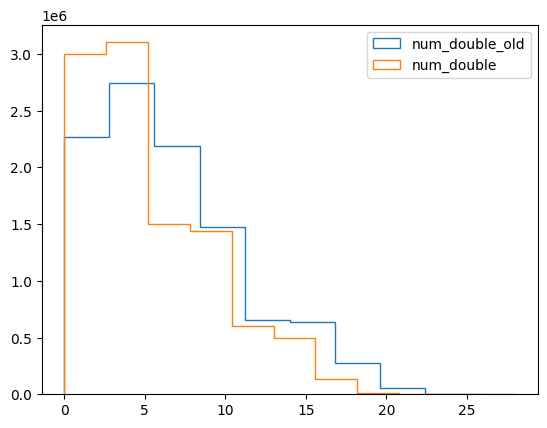

In [15]:
plt.hist(num_double_old, label='num_double_old', histtype='step')
plt.hist(num_double, label='num_double', histtype='step')
plt.legend()


In [43]:
diff_hist = []
for i in range(2,20):
    ind = double_detector(data[i])
    # print('event')
    for p in ind:
        t1 = data[i][p[0],-1]
        t2 = data[i][p[1],-1]
        diff_hist.append(np.abs(t1-t2))

In [ ]:
plt.hist(diff_hist)

In [22]:
1.0332375 * std[-1] + mean[-1]

4.973735228854418

In [18]:
diff = 0.20915855-(-0.8196427)
diff

1.02880125

In [24]:
num=0
for i in tqdm(data):
    index_double = double_detector(i)
    if len(index_double) == 0:
        num+=1
num, len(data)

100%|██████████| 10291149/10291149 [25:55<00:00, 6615.37it/s]


(494100, 10291149)

In [27]:
indexes = []
for j, i in tqdm(enumerate(data), total=len(data)):
    index = i[:,-1]>12
    if index.sum()>0:
        indexes.append(j)
len(indexes)

100%|██████████| 10291149/10291149 [00:33<00:00, 303508.05it/s]


15876

In [28]:
indexes[:3]

[823, 911, 1012]

array([[ 2.7473695 ,  0.3224259 , -0.50415725, -0.27368793, -2.1087584 ,
         1.7266406 ],
       [ 2.1111724 , -0.6661157 , -0.47692895, -0.2705846 , -1.8131579 ,
        -0.01749929],
       [ 2.1111724 , -0.6661157 , -0.47692895, -0.2705846 , -1.8131579 ,
         1.011302  ],
       [ 2.0863614 ,  0.14562564, -0.47401693, -0.27126002, -1.5828127 ,
         0.03635205],
       [ 2.218901  ,  0.9582226 , -0.36186185, -0.2706628 , -1.4905072 ,
        -0.36994407],
       [ 2.218901  ,  0.9582226 , -0.36186185, -0.2706628 , -1.4905072 ,
         1.5188708 ],
       [ 2.218901  ,  0.9582226 , -0.36186185, -0.2706628 , -1.4905072 ,
        12.265021  ],
       [ 1.2700452 , -0.6718512 , -0.39571127, -0.24746417, -1.0883793 ,
        -0.76458585],
       [ 1.2700452 , -0.6718512 , -0.39571127, -0.24746417, -1.0883793 ,
         0.26421553],
       [ 1.2700452 , -0.6718512 , -0.39571127, -0.24746417, -1.0883793 ,
         1.2930168 ]], dtype=float32)

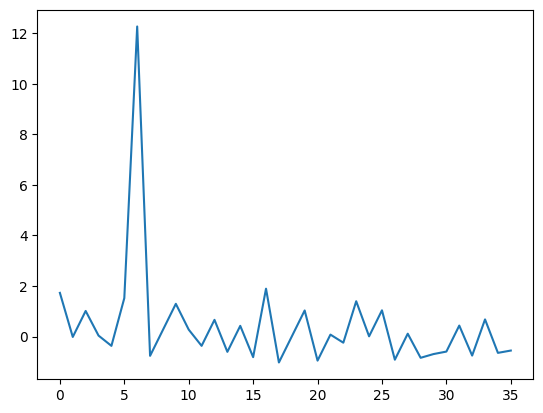

In [33]:
i=1012
plt.plot(data[i][:,-1])
data[i][:10]

In [35]:
print(12.265021 - 1.5188708)

10.7461502


array([[ 3.4254003e+00,  4.0402004e-01,  1.2178896e-03,  5.8151245e-01,
        -8.2180004e+00,  6.6900005e+00],
       [ 2.6312799e+00, -8.3105701e-01,  1.7712405e-03,  2.7345734e+00,
        -7.1580000e+00,  2.3499999e+00],
       [ 2.6312799e+00, -8.3105701e-01,  1.7712405e-03,  2.7345734e+00,
        -7.1580000e+00,  4.9099998e+00],
       [ 2.6003101e+00,  1.8312700e-01,  1.8304205e-03,  2.2659760e+00,
        -6.3319998e+00,  2.4840000e+00],
       [ 2.7657499e+00,  1.1983800e+00,  4.1097105e-03,  2.6803131e+00,
        -6.0009999e+00,  1.4730000e+00],
       [ 2.7657499e+00,  1.1983800e+00,  4.1097105e-03,  2.6803131e+00,
        -6.0009999e+00,  6.1730003e+00],
       [ 2.7657499e+00,  1.1983800e+00,  4.1097105e-03,  2.6803131e+00,
        -6.0009999e+00,  3.2912998e+01],
       [ 1.5813600e+00, -8.3822292e-01,  3.4218002e-03,  1.8775299e+01,
        -4.5590000e+00,  4.9099994e-01],
       [ 1.5813600e+00, -8.3822292e-01,  3.4218002e-03,  1.8775299e+01,
        -4.5590000e+00, 

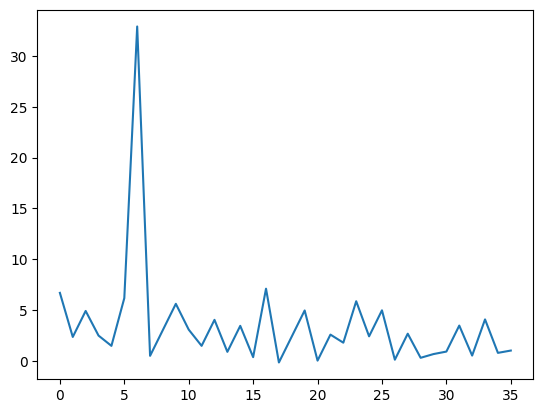

In [34]:
plt.plot(data_unnorm[i][:,-1])
data_unnorm[i][:10]

In [37]:
print(3.2912998e+01 - 6.1730003e+00)
print(3.2912998e+01 - 1.4730000e+00)


26.739997700000004
31.439998000000003


array([[-8.8727397e-01, -1.6099602e+00,  9.7756851e-01, -2.7359921e-01,
        -8.4046531e-01,  1.5209225e-01],
       [-8.8727397e-01, -1.6099602e+00,  9.7756851e-01, -2.7359921e-01,
        -8.4046531e-01,  1.2586122e+01],
       [-1.6854364e+00, -8.0774683e-01,  1.4311951e+00, -2.7347338e-01,
        -7.0130998e-01,  3.6910501e-01],
       [-8.5918263e-02, -1.6121454e+00,  7.0994610e-01, -2.7311185e-01,
        -6.1290878e-01, -4.7322610e-01],
       [-8.8651294e-01, -8.1005192e-01,  1.3054833e+00, -2.6133361e-01,
        -4.7737879e-01, -5.7208747e-01],
       [-8.8651294e-01, -8.1005192e-01,  1.3054833e+00, -2.6133361e-01,
        -4.7737879e-01,  4.5671386e-01],
       [-8.8651294e-01, -8.1005192e-01,  1.3054833e+00, -2.6133361e-01,
        -4.7737879e-01,  2.3857162e+00],
       [-1.6810862e+00, -7.8309579e-03,  1.2424797e+00, -2.7227730e-01,
        -3.2651106e-01, -1.7101568e-01],
       [-1.6810862e+00, -7.8309579e-03,  1.2424797e+00, -2.7227730e-01,
        -3.2651106e-01, 

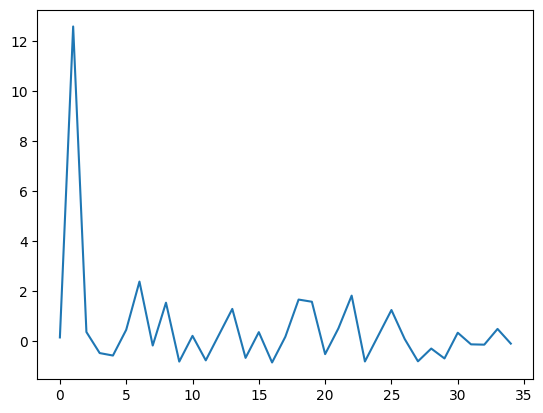

In [38]:
i=911
plt.plot(data[i][:,-1])
data[i][:10]

In [39]:
1.2586122e+01 - 1.5209225e-01

12.434029749999999

array([[-1.1114700e+00, -2.0102899e+00,  3.1330500e-02,  6.4306641e-01,
        -3.6700001e+00,  2.7720001e+00],
       [-1.1114700e+00, -2.0102899e+00,  3.1330500e-02,  6.4306641e-01,
        -3.6700001e+00,  3.3712002e+01],
       [-2.1077600e+00, -1.0080100e+00,  4.0549401e-02,  7.3036194e-01,
        -3.1710000e+00,  3.3120000e+00],
       [-1.1119400e-01, -2.0130200e+00,  2.5891701e-02,  9.8120117e-01,
        -2.8540001e+00,  1.2160000e+00],
       [-1.1105200e+00, -1.0108900e+00,  3.7994605e-02,  9.1528168e+00,
        -2.3680000e+00,  9.7000003e-01],
       [-1.1105200e+00, -1.0108900e+00,  3.7994605e-02,  9.1528168e+00,
        -2.3680000e+00,  3.5300000e+00],
       [-1.1105200e+00, -1.0108900e+00,  3.7994605e-02,  9.1528168e+00,
        -2.3680000e+00,  8.3299999e+00],
       [-2.1023300e+00, -8.6006196e-03,  3.6714200e-02,  1.5601959e+00,
        -1.8270000e+00,  1.9680001e+00],
       [-2.1023300e+00, -8.6006196e-03,  3.6714200e-02,  1.5601959e+00,
        -1.8270000e+00, 

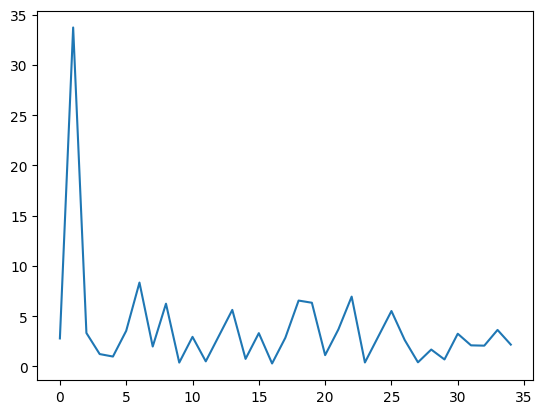

In [40]:
plt.plot(data_unnorm[i][:,-1])
data_unnorm[i][:10]

In [ ]:
3.3712002e+01 - 2.7720001e+00

30.9400019

: 